In [1]:
%pip install -U nbformat plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

### №1 Нахождение порядка аппроксимации методов Рунге-Кутте

На примере:

$$ y' = 2y, $$

$$ y(0) = 1 $$


In [84]:
a = 0
b = 2
n = 1000
y_a = 1
x_values = np.linspace(a, b, n + 1)
x_values_x2 = np.linspace(a, b, n * 2 + 1)

In [60]:
def max_diff_1(f1, f2):
    return max(abs(f1 - f2))


def order_approximation_1(calculated, calculated_x2, reference, reference_x2):
    epsilon1 = max_diff_1(calculated, reference)
    epsilon2 = max_diff_1(calculated_x2, reference_x2)
    return np.log2(epsilon1 / epsilon2)

In [55]:
def f1(x, y):
    return 2 * y


solution1 = lambda x: np.exp(2 * x)

#### Реальное решение

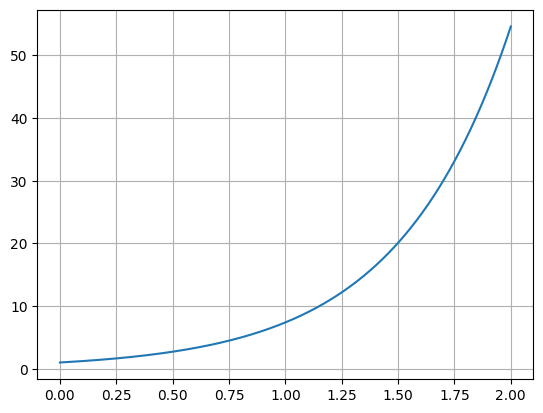

In [85]:
y_values = solution1(x_values)
plt.plot(x_values, y_values)
plt.grid()
plt.show()

#### Явный метод Эйлера

In [56]:
def explicit_euler_method(function, a, b, n, ya):
    x = np.linspace(a, b, n + 1)
    h = (b - a) / n
    y = np.zeros(n + 1)
    y[0] = ya
    for i in range(n):
        y[i + 1] = y[i] + h * function(x[i], y[i])
    return y

Порядок аппроцсимации явного метода Эйлера: 0.995210181008846


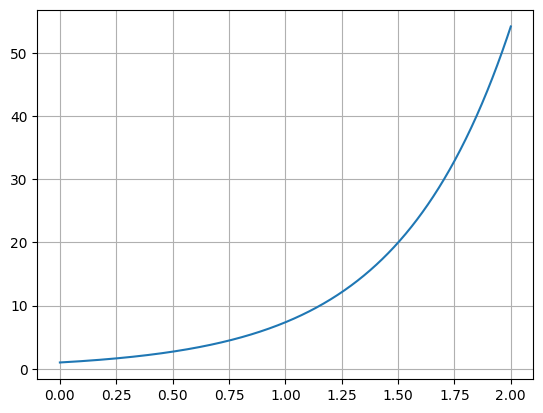

In [65]:
y_values = explicit_euler_method(f1, a, b, n, y_a)
y_values_x2 = explicit_euler_method(f1, a, b, n * 2, y_a)
print("Порядок аппроцсимации явного метода Эйлера:",
      order_approximation_1(y_values, y_values_x2, solution1(x_values), solution1(x_values_x2)))
plt.plot(x_values, y_values)
plt.grid()
plt.show()

#### Неявный метод Эйлера

$$ y_{n+1} = y_n + hf(x_{n+1}, y_{n+1}) $$

$$ y_{n+1} = y_n + 2h * y_{n+1} $$

$$ (1 - 2h) * y_{n+1} = y_n $$

$$ y_{n+1} = (1 - 2h)^{-1} * y_n $$

In [67]:
def implicit_euler_method(a, b, n, ya):
    h = (b - a) / n
    y = np.zeros(n + 1)
    y[0] = ya

    for i in range(n):
        y[i + 1] = y[i] / (1 - 2 * h)
    return y

Порядок аппроцсимации неявного метода Эйлера: 1.004828291377637


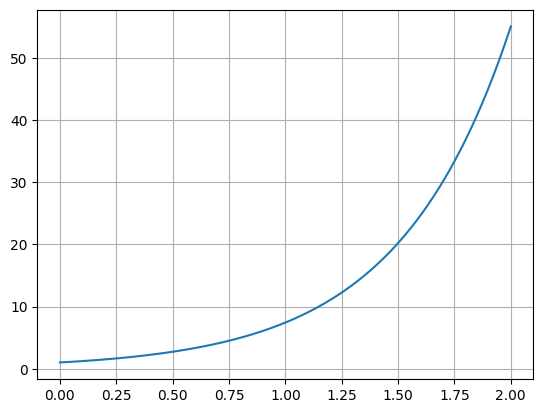

In [69]:
y_values = implicit_euler_method(a, b, n, y_a)
y_values_x2 = implicit_euler_method(a, b, n * 2, y_a)
print("Порядок аппроцсимации неявного метода Эйлера:",
      order_approximation_1(y_values, y_values_x2, solution1(x_values), solution1(x_values_x2)))
plt.plot(x_values, y_values)
plt.grid()
plt.show()

#### Метод Рунге-Кутте 4-го порядка

In [70]:
def rk4(function, a, b, n, ya):
    x = np.linspace(a, b, n + 1)
    h = (b - a) / n
    y = np.zeros(n + 1)
    y[0] = ya
    for i in range(n):
        k1 = function(x[i], y[i])
        k2 = function(x[i] + h / 2, y[i] + h * k1 / 2)
        k3 = function(x[i] + h / 2, y[i] + h * k2 / 2)
        k4 = function(x[i] + h, y[i] + h * k3)
        y[i + 1] = y[i] + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return y

Порядок аппроцсимации метода Рунге-Кутта четвертого порядка: 3.998786362418026


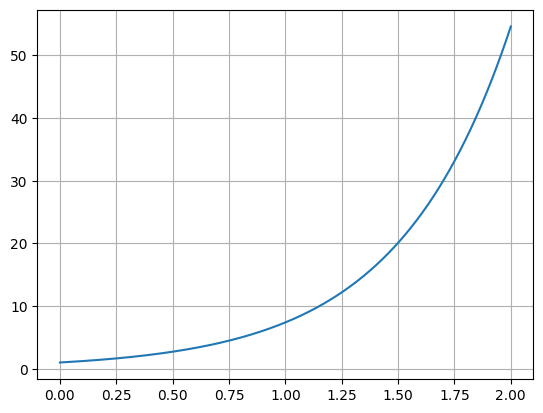

In [71]:
y_values = rk4(f1, a, b, n, y_a)
y_values_x2 = rk4(f1, a, b, n * 2, y_a)
print("Порядок аппроцсимации метода Рунге-Кутта четвертого порядка:",
      order_approximation_1(y_values, y_values_x2, solution1(x_values), solution1(x_values_x2)))
plt.plot(x_values, y_values)
plt.grid()
plt.show()

### №2 Решение жеской системы
$$ u′ = 998u + 1998v$$
$$ v′ = −999u − 1999v

https://physics.susu.ru/vorontsov/ode/info.html

Решение для начальных данных v(0) = u(0) = 1

$$ u(t)=4e^{−t}−3e^{−1000t} $$

$$ v(t)=−2e^{−t}+3e^{−1000t}

In [51]:
a = 0
b = 0.05
n = 20
x_values = np.linspace(a, b, n + 1)
u_a = 1
v_a = 1

In [12]:
def max_diff(f1, f2):
    return max(np.sqrt((f1[0] - f2[0])**2 + (f1[1] - f2[1])**2))


def order_approximation(calculated, calculated_x2, reference, reference_x2):
    epsilon1 = max_diff(calculated, reference)
    epsilon2 = max_diff(calculated_x2, reference_x2)
    return np.log2(epsilon1 / epsilon2)

In [13]:
def function2(x, u, v):
    return (998 * u + 1998 * v, -999 * u - 1999 * v)

In [14]:
def solution2(x):
    u = 4 * np.exp(-x) - 3 * np.exp(- 1000 * x)
    v = -2 * np.exp(-x) + 3 * np.exp(-1000 * x)
    return u, v

#### Реальное решение

In [52]:
u_values = solution2(x_values)[0]
v_values = solution2(x_values)[1]
fig = go.Figure(data=go.Scatter3d(
    x=x_values, y=u_values, z=v_values,
    mode='lines',
    line=dict(color='blue', width=4)
))

fig.update_layout(
    scene=dict(
        xaxis_title='t',
        yaxis_title='u(t)',
        zaxis_title='v(t)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

#### Решение явным методом

In [49]:
def explicit_euler_method_2(function, a, b, n, ua, va):
    x = np.linspace(a, b, n + 1)
    h = (b - a) / n
    u = np.zeros(n + 1)
    v = np.zeros(n + 1)
    u[0] = ua
    v[0] = va
    for i in range(n):
        fi = function(x[i], u[i], v[i])
        u[i + 1] = u[i] + h * fi[0]
        v[i + 1] = v[i] + h * fi[1]
    return u, v

In [53]:
u_values, v_values = explicit_euler_method_2(function2, a, b, n, u_a, v_a)
fig = go.Figure(data=go.Scatter3d(
    x=x_values, y=u_values, z=v_values,
    mode='lines',
    line=dict(color='blue', width=4)
))

fig.update_layout(
    scene=dict(
        xaxis_title='t',
        yaxis_title='u(t)',
        zaxis_title='v(t)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

#### Решение неявным методом

$$ y_{n+1} = y_n + hf(x_{n+1}, y_{n+1}) $$

$$ y_{n+1} = y_n + hA * y_{n+1} $$

$$ (I - hA) * y_{n+1} = y_n $$

$$ y_{n+1} = (I - hA)^{-1} * y_n $$

In [ ]:
def implicit_euler_method_2(a, b, n, ua, va):
    h = (b - a) / n
    u = np.zeros(n + 1)
    v = np.zeros(n + 1)
    u[0] = ua
    v[0] = va

    A = np.array([[998, 1998],
                  [-999, -1999]])
    I = np.eye(2)
    M = I - h * A
    
    M_inv = np.linalg.inv(M)

    for i in range(n):
        u[i + 1], v[i + 1] = M_inv @ [u[i], v[i]]
    return u, v

In [ ]:
u_values, v_values = implicit_euler_method_2(a, b, n, u_a, v_a)

fig = go.Figure(data=go.Scatter3d(
    x=x_values, y=u_values, z=v_values,
    mode='lines',
    line=dict(color='blue', width=4)
))

fig.update_layout(
    scene=dict(
        xaxis_title='t',
        yaxis_title='u(t)',
        zaxis_title='v(t)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

### №3 Исследование аттрактора Лоренца с помощью метода Рунге-Кутты 4-го порядка

x' = σ(y − x)

y' = x(r − z) − y

z' = xy − bz

σ = 10, b = 8/3, r - любое

https://ru.wikipedia.org/wiki/%D0%90%D1%82%D1%82%D1%80%D0%B0%D0%BA%D1%82%D0%BE%D1%80_%D0%9B%D0%BE%D1%80%D0%B5%D0%BD%D1%86%D0%B0

In [72]:
r = 24

a = -10
b = 10
n = 1000
t_values = np.linspace(a, b, n + 1)

In [73]:
def function3(x, y, z, t):
    return (10 * (y - x), 
            x * (r - z) - y, 
            x * y - 8 / 3 * z)

In [74]:
def rk4_3(function, a, b, n, xa, ya, za):
    t = np.linspace(a, b, n + 1)
    h = (b - a) / n
    x = np.zeros(n + 1)
    y = np.zeros(n + 1)
    z = np.zeros(n + 1)
    x[0] = xa
    y[0] = ya
    z[0] = za
    for i in range(n):
        k1 = function(x[i], y[i], z[i], t[i])
        k2 = function(x[i] + h * k1[0] / 2, y[i] + h * k1[1] / 2, z[i] + h * k1[2] / 2, t[i] + h / 2)
        k3 = function(x[i] + h * k2[0] / 2, y[i] + h * k2[1] / 2, z[i] + h * k2[2] / 2, t[i] + h / 2)
        k4 = function(x[i] + h * k3[0], y[i] + h * k3[1], z[i] + h * k3[2], t[i] + h)
        x[i + 1] = x[i] + h / 6 * (k1[0] + 2 * k2[0] + 2 * k3[0] + k4[0])
        y[i + 1] = y[i] + h / 6 * (k1[1] + 2 * k2[1] + 2 * k3[1] + k4[1])
        z[i + 1] = z[i] + h / 6 * (k1[2] + 2 * k2[2] + 2 * k3[2] + k4[2])
    return x, y, z

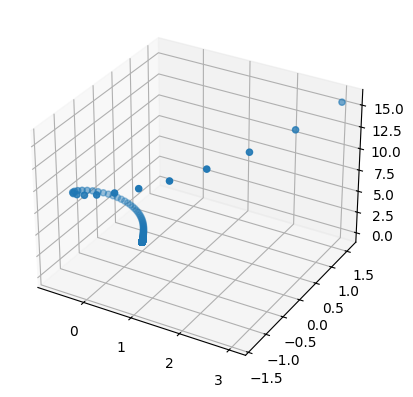

In [75]:
r = 0.3

x_values, y_values, z_values = rk4_3(function3, a, b, n, 3.051522, 1.582542, 15.62388)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_values, y_values, z_values)
plt.grid()
plt.show()

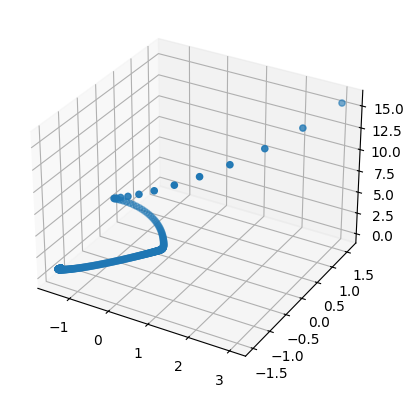

In [76]:
r = 1.8

x_values, y_values, z_values = rk4_3(function3, a, b, n, 3.051522, 1.582542, 15.62388)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_values, y_values, z_values)
plt.grid()
plt.show()

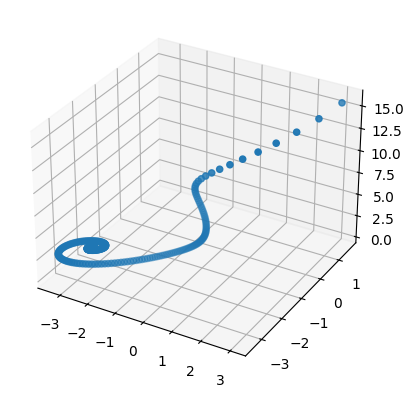

In [77]:
r = 3.7

x_values, y_values, z_values = rk4_3(function3, a, b, n, 3.051522, 1.582542, 15.62388)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_values, y_values, z_values)
plt.grid()
plt.show()

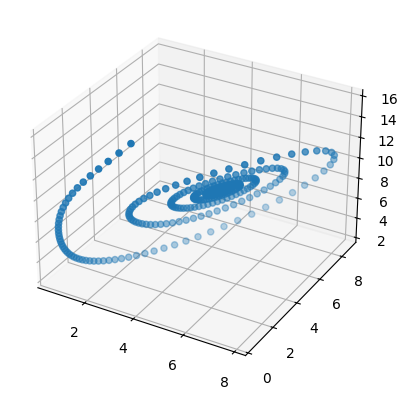

In [78]:
r = 10

x_values, y_values, z_values = rk4_3(function3, a, b, n, 3.051522, 1.582542, 15.62388)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_values, y_values, z_values)
plt.grid()
plt.show()

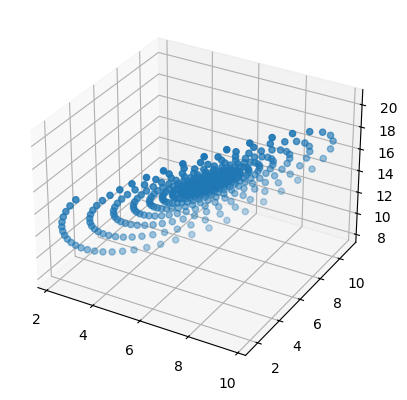

In [79]:
r = 16

x_values, y_values, z_values = rk4_3(function3, a, b, n, 3.051522, 1.582542, 15.62388)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_values, y_values, z_values)
plt.grid()
plt.show()

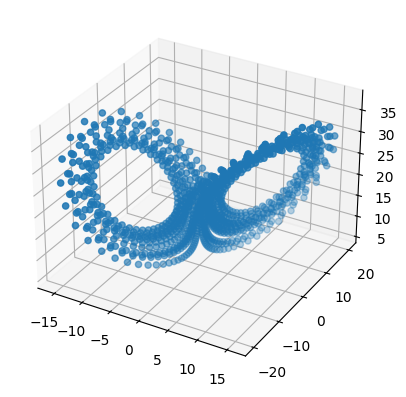

In [80]:
r = 24.06
x_values, y_values, z_values = rk4_3(function3, a, b, n, 3.051522, 1.582542, 15.62388)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_values, y_values, z_values)
plt.grid()
plt.show()

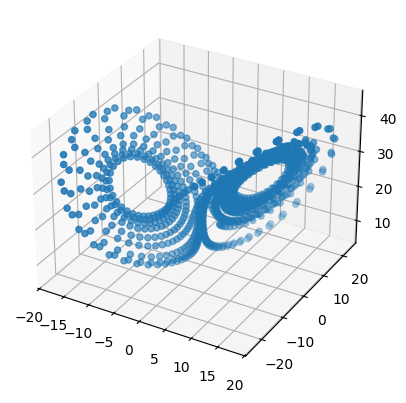

In [81]:
r = 28

x_values, y_values, z_values = rk4_3(function3, a, b, n, 3.051522, 1.582542, 15.62388)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_values, y_values, z_values)
plt.grid()
plt.show()

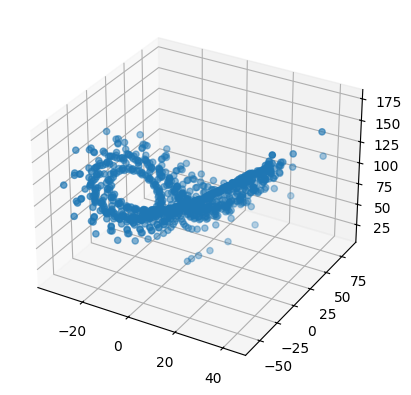

In [82]:
r = 100

x_values, y_values, z_values = rk4_3(function3, a, b, n, 3.051522, 1.582542, 15.62388)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_values, y_values, z_values)
plt.grid()
plt.show()